In [1]:
import os
import re

In [2]:

base_dir = "results"
my_fold_scores = {}

# Regex to capture val_acc
val_acc_pattern = re.compile(r"val_acc is ([0-9.]+)")

for i in range(1, 6):  # fold1 to fold5
    fold_dir = os.path.join(base_dir, f"fold{i}")
    file_path = os.path.join(fold_dir, f"results{i}.txt")

    last_val_acc = None
    last_seen_val = None

    with open(file_path, "r") as f:
        for line in f:
            # If line contains val_acc, store it temporarily
            match = val_acc_pattern.search(line)
            if match:
                last_seen_val = float(match.group(1))

            # When "Saving model ..." appears, lock the latest val_acc
            if "Saving model" in line and last_seen_val is not None:
                last_val_acc = last_seen_val

    my_fold_scores[i] = last_val_acc

print(my_fold_scores)

{1: 0.91, 2: 0.9125, 3: 0.91, 4: 0.9325, 5: 0.905}


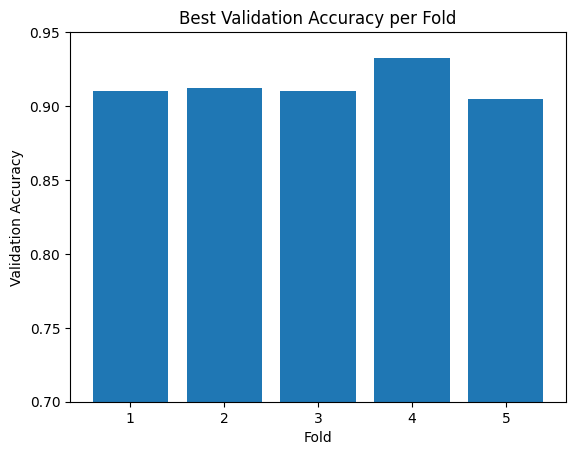

In [3]:
import matplotlib.pyplot as plt

folds = sorted(my_fold_scores.keys())
scores = [my_fold_scores[f] for f in folds]

plt.figure()
plt.bar(folds, scores)

plt.xlabel("Fold")
plt.ylabel("Validation Accuracy")
plt.title("Best Validation Accuracy per Fold")
plt.ylim(0.7, 0.95)

plt.show()

In [4]:
paper_scores = {1: 0.91, 2: 0.92, 3: 0.915, 4: 0.935, 5: 0.905}

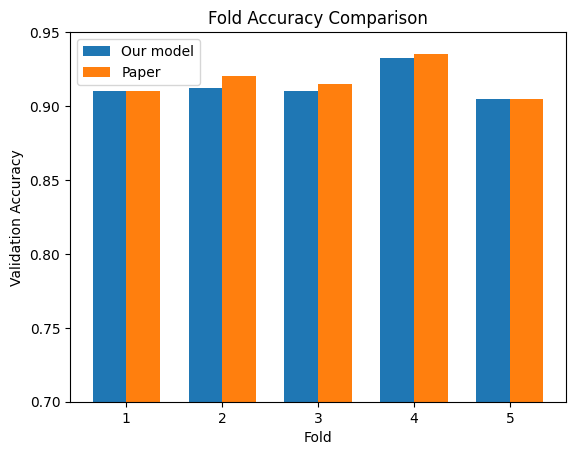

In [5]:
import numpy as np
folds = sorted(my_fold_scores.keys())

my_vals = [my_fold_scores[f] for f in folds]
paper_vals = [paper_scores[f] for f in folds]

x = np.arange(len(folds))  # positions
width = 0.35  # bar width

plt.figure()

plt.bar(x - width/2, my_vals, width, label="Our model")
plt.bar(x + width/2, paper_vals, width, label="Paper")

plt.xticks(x, folds)
plt.xlabel("Fold")
plt.ylabel("Validation Accuracy")
plt.title("Fold Accuracy Comparison")
plt.ylim(0.7, 0.95)
plt.legend()

plt.show()